In [2]:
import pandas as pd

network_data= pd.read_csv("/content/Jacobite_sheets_simple_data.csv")
network_data.head()

,Source,Target,Weight,Unnamed: 3
0,Unknown,Annandale,2,NaN
1,Unknown,Archibald Brounlie,1,NaN
2,Unknown,Dunfermline,3,NaN
3,Unknown,Jacobites,2,NaN
4,Unknown,Langton,1,NaN


In [4]:
network_data.drop('Unnamed: 3', axis=1)

,Source,Target,Weight
0,Unknown,Annandale,2
1,Unknown,Archibald Brounlie,1
2,Unknown,Dunfermline,3
3,Unknown,Jacobites,2
4,Unknown,Langton,1
...,...,...,...
249,William McKay,Livingston,2
250,William Paterson,Breadalbane,1
251,William Riach,Melville,1
252,Williamite Spy,Melville,1


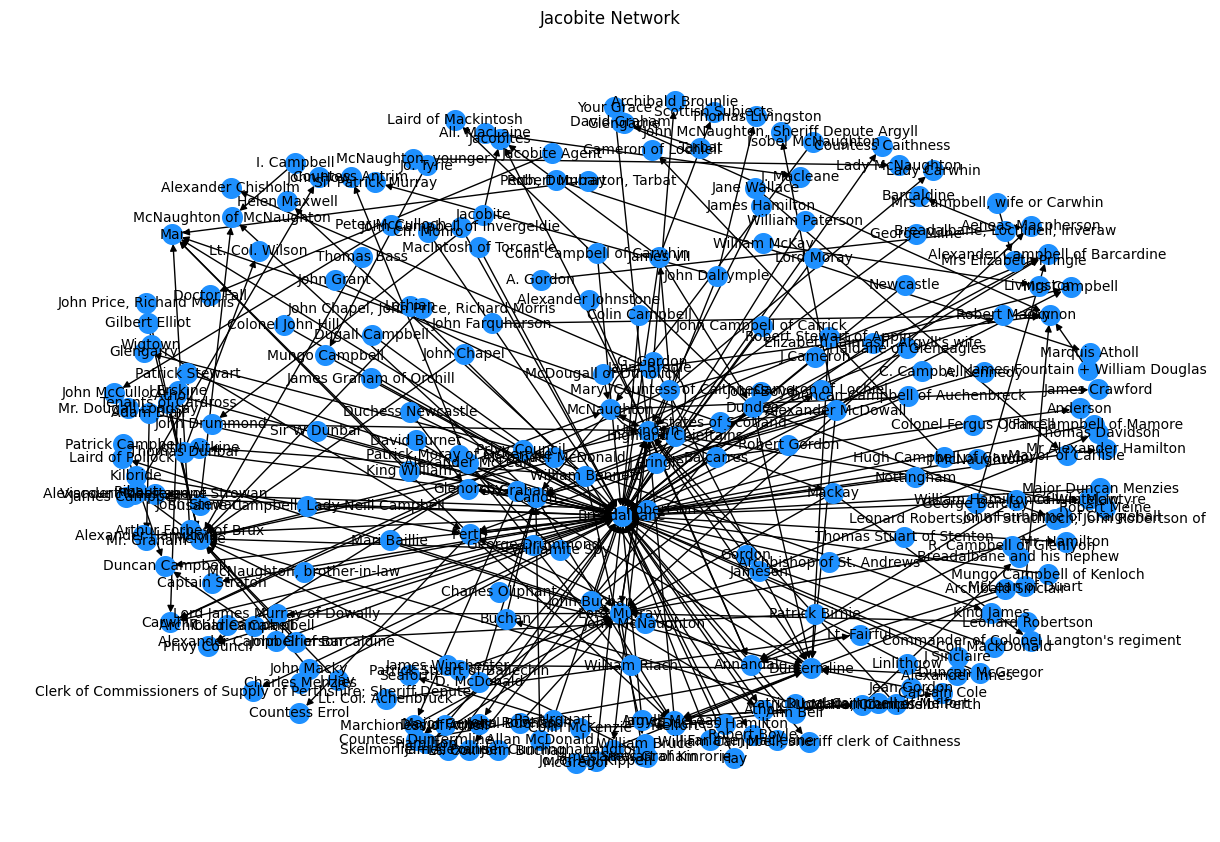

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G= nx.DiGraph()
for idx, row in network_data.iterrows():
    G.add_edge(row['Source'], row['Target'])

plt.figure(figsize=(12,8))
pos= nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, with_labels=True, node_color='dodgerblue', edge_color='black', node_size=200,font_size=10)
plt.title("Jacobite Network")
plt.show()

In [6]:
sender_count=network_data['Source'].value_counts()
print(sender_count.head(10))

Source
Breadalbane                    19
Unknown                        11
Alexander McDowall              5
William Bennett                 5
Perth                           5
Canon                           4
Dundee                          4
James VII                       4
Alexander McLean                4
Mary, Countess of Caithness     4
Name: count, dtype: int64


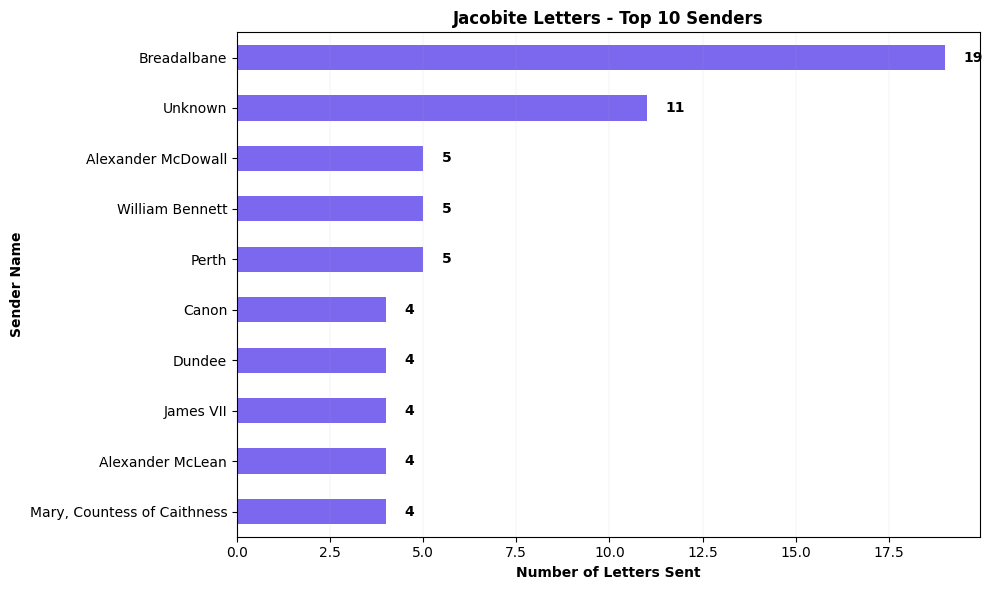

In [7]:
network_top_senders = sender_count.head(10)

plt.figure(figsize=(10,6))
ax = network_top_senders.plot(kind='barh', color='mediumslateblue')

plt.xlabel("Number of Letters Sent", weight='bold')
plt.ylabel("Sender Name", weight='bold')
plt.title('Jacobite Letters - Top 10 Senders', weight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(linewidth=0.1, axis='x')

for i, v in enumerate(network_top_senders):
    ax.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

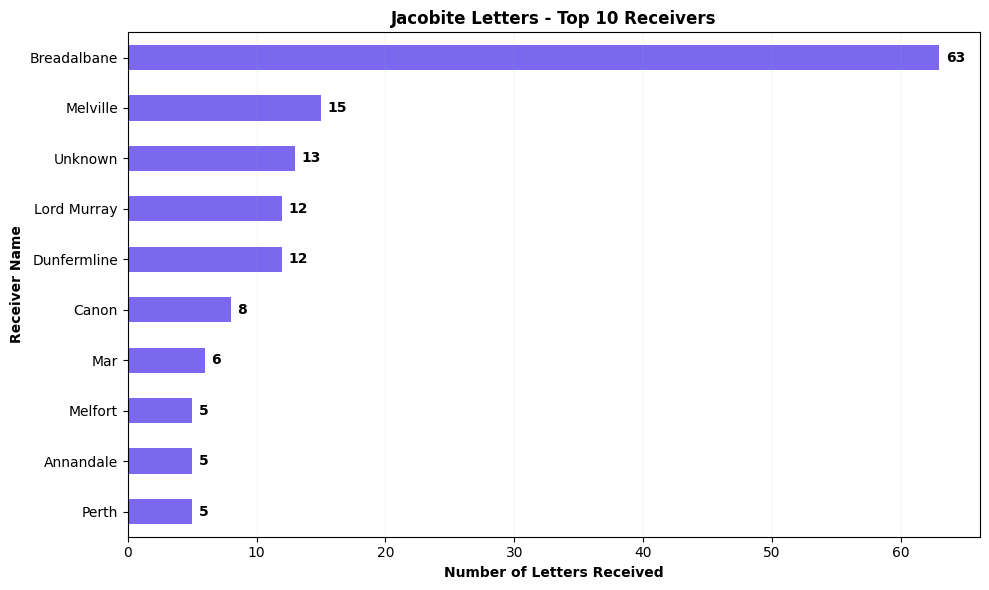

In [9]:
receiver_count = network_data['Target'].value_counts()
network_top_receivers = receiver_count.head(10)

plt.figure(figsize=(10,6))
ax = network_top_receivers.plot(kind='barh', color='mediumslateblue')

plt.xlabel("Number of Letters Received", weight='bold')
plt.ylabel("Receiver Name", weight='bold')
plt.title('Jacobite Letters - Top 10 Receivers', weight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(linewidth=0.1, axis='x')

for i, v in enumerate(network_top_receivers):
    ax.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

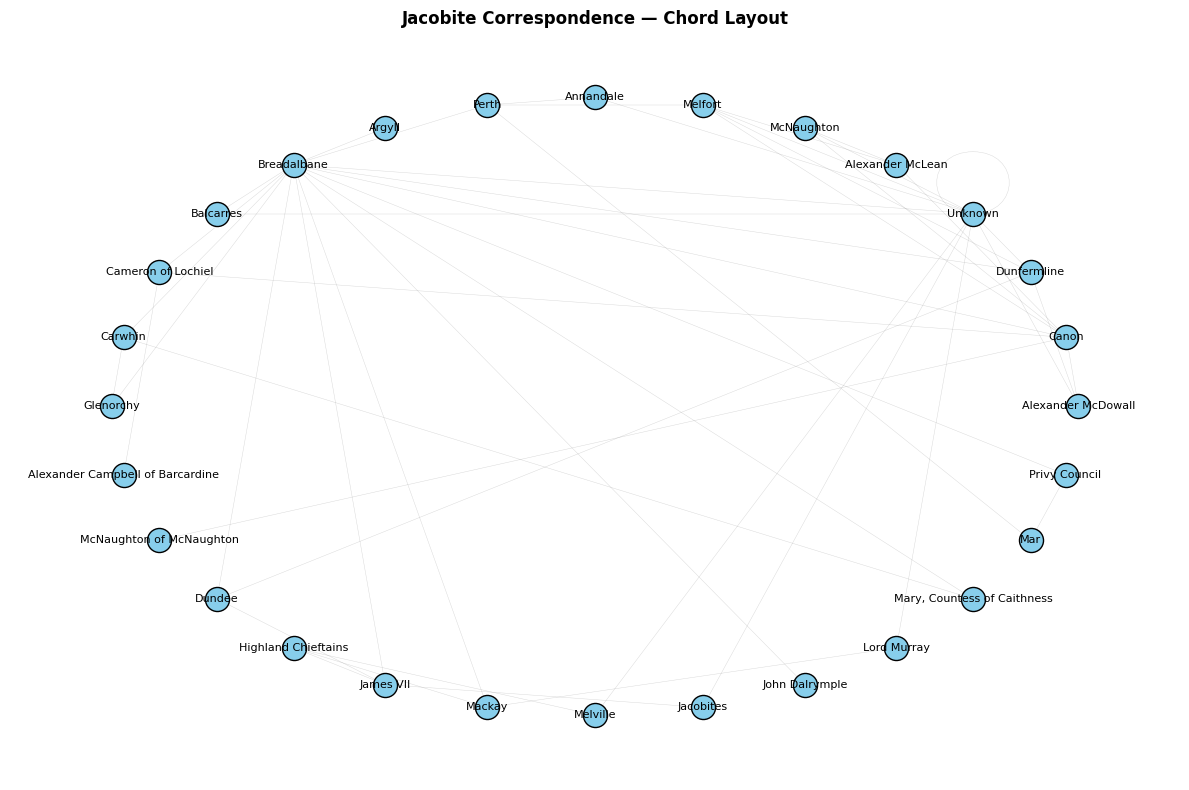

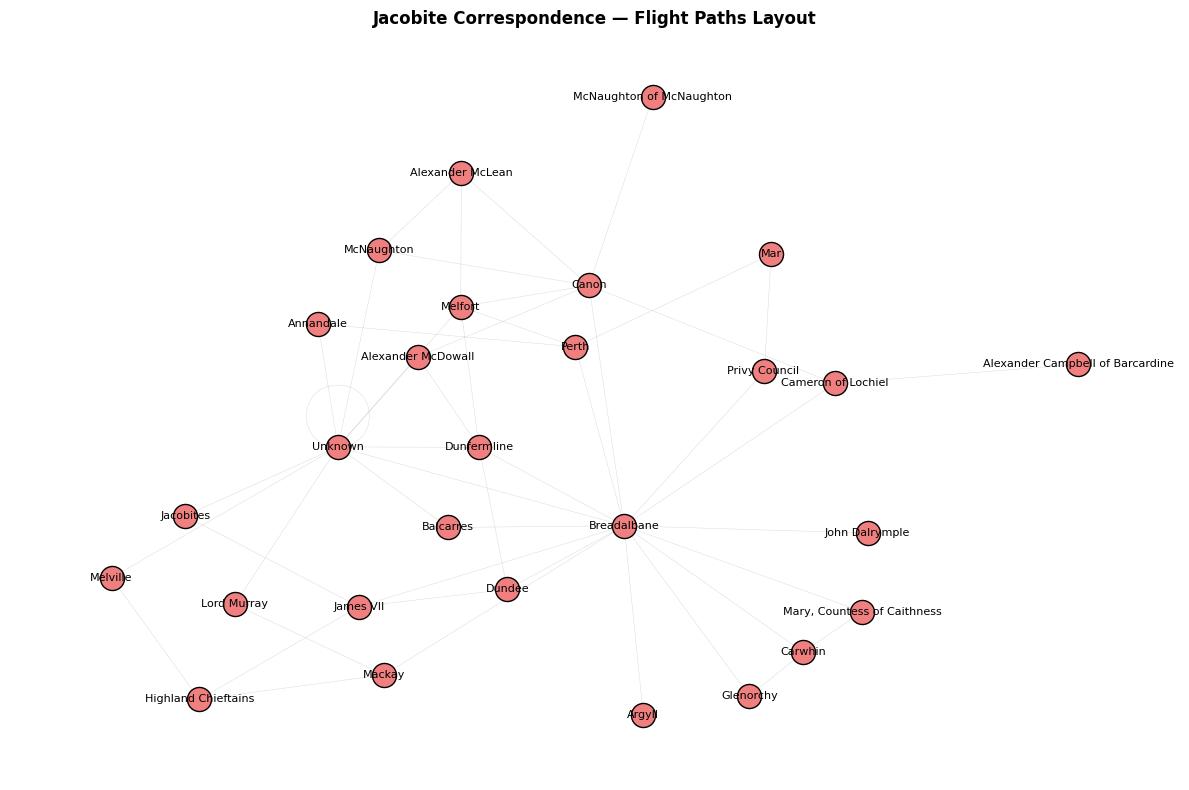

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

sender_col = 'Source'
receiver_col = 'Target'

edge_counts = (
    network_data.groupby([sender_col, receiver_col])
    .size()
    .reset_index(name='count'))
top_n = 30
top_nodes = pd.concat([
    edge_counts[sender_col],
    edge_counts[receiver_col]
]).value_counts().head(top_n).index

edge_counts = edge_counts[
    edge_counts[sender_col].isin(top_nodes) &
    edge_counts[receiver_col].isin(top_nodes)]

G = nx.Graph()
for _, row in edge_counts.iterrows():
    G.add_edge(row[sender_col], row[receiver_col], weight=row['count'])

pos_circle = nx.circular_layout(G)

pos_spring = nx.spring_layout(G, seed=42, k=0.4)

plt.figure(figsize=(12, 8))
edges = nx.draw_networkx_edges(G, pos_circle, alpha=0.3, width=[d['weight']/3 for _, _, d in G.edges(data=True)], edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos_circle, node_size=300, node_color='skyblue', edgecolors='black')
labels = nx.draw_networkx_labels(G, pos_circle, font_size=8)
plt.axis('off')
plt.title('Jacobite Correspondence — Chord Layout', fontweight='bold')
plt.tight_layout()
plt.savefig("jacobite_chord.png", dpi=300)
plt.show()

plt.figure(figsize=(12, 8))
edges = nx.draw_networkx_edges(G, pos_spring, alpha=0.3, width=[d['weight']/3 for _, _, d in G.edges(data=True)], edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos_spring, node_size=300, node_color='lightcoral', edgecolors='black')
labels = nx.draw_networkx_labels(G, pos_spring, font_size=8)
plt.axis('off')
plt.title('Jacobite Correspondence — Flight Paths Layout', fontweight='bold')
plt.tight_layout()
plt.savefig("jacobite_flightpaths.png", dpi=300)
plt.show()